# Pipeline coverage summary

Scan the pipeline image tree under `/lustre/pipeline/images` and summarize
subband, LST hour, and observation-day coverage for every `(LST hour bin,
observation day)` pair that has at least one `Run_*` directory.

For per-day Wideband QA, FITS→Zarr conversion, and interactive review, see
`pipeline_qa_check.ipynb`.


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PIPELINE_ROOT = Path("/lustre/pipeline/exopipe/phase1/")

RUN_PATTERN = re.compile(r"Run_(\d{8})_(\d{6})")
DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}$")
HOUR_PATTERN = re.compile(r"^\d{2}h$")
WIDEBAND_SUBDIR = Path("Wideband")


In [2]:
def run_sort_key(run_dir: Path) -> str:
    """Sort key from Run_YYYYMMDD_HHMMSS directory name."""
    match = RUN_PATTERN.match(run_dir.name)
    if match is None:
        return run_dir.name
    return match.group(1) + match.group(2)


def list_runs(day_dir: Path) -> list[Path]:
    """List Run_* directories under one observation-day folder."""
    return [
        path
        for path in day_dir.iterdir()
        if path.is_dir() and path.name.startswith("Run_")
    ]


def run_has_wideband(run_dir: Path) -> bool:
    """True when a Run_* directory contains a Wideband subdirectory."""
    return (run_dir / WIDEBAND_SUBDIR).is_dir()


def select_run_dir(day_dir: Path) -> Path | None:
    """Pick the newest Run_* directory under a day folder."""
    runs = list_runs(day_dir)
    if not runs:
        return None
    return max(runs, key=run_sort_key)


def list_subbands(run_dir: Path) -> list[str]:
    """List subband directories (e.g. 23MHz) under a run — no file I/O."""
    return sorted(
        path.name
        for path in run_dir.iterdir()
        if path.is_dir() and path.name.endswith("MHz")
    )


def discover_hour_bins(root: Path) -> list[str]:
    return sorted(
        (path.name for path in root.iterdir() if path.is_dir() and HOUR_PATTERN.match(path.name)),
        key=lambda name: int(name[:-1]),
    )


def scan_coverage(root: Path = PIPELINE_ROOT) -> pd.DataFrame:
    """Build one row per (LST hour bin, observation day) with pipeline products."""
    rows: list[dict[str, object]] = []

    for hour in discover_hour_bins(root):
        hour_dir = root / hour
        for day_dir in sorted(hour_dir.iterdir()):
            if not day_dir.is_dir() or not DATE_PATTERN.match(day_dir.name):
                continue

            all_runs = list_runs(day_dir)
            if not all_runs:
                continue

            selected = select_run_dir(day_dir)
            assert selected is not None
            subbands = list_subbands(selected)

            rows.append(
                {
                    "lst_hour": hour,
                    "obs_date": day_dir.name,
                    "n_runs": len(all_runs),
                    "n_wideband_runs": sum(1 for run in all_runs if run_has_wideband(run)),
                    "has_wideband": any(run_has_wideband(run) for run in all_runs),
                    "latest_run": selected.name,
                    "n_subbands": len(subbands),
                    "subbands": ", ".join(subbands),
                    "run_path": str(selected),
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["lst_hour_num"] = df["lst_hour"].str.replace("h", "", regex=False).astype(int)
    df["obs_date"] = pd.to_datetime(df["obs_date"])
    return df.sort_values(["obs_date", "lst_hour_num"]).reset_index(drop=True)


In [3]:
coverage = scan_coverage()

if coverage.empty:
    raise FileNotFoundError(f"No hour/day coverage found under {PIPELINE_ROOT}")

n_days = coverage["obs_date"].nunique()
n_hours = coverage["lst_hour"].nunique()
n_pairs = len(coverage)

print(f"Pipeline root: {PIPELINE_ROOT}")
print(f"Observation days: {n_days}")
print(f"LST hour bins with data: {n_hours}")
print(f"Hour/day pairs: {n_pairs}")
print(f"Date range: {coverage['obs_date'].min():%Y-%m-%d} → {coverage['obs_date'].max():%Y-%m-%d}")

coverage.head(10)

Pipeline root: /lustre/pipeline/exopipe/phase1
Observation days: 34
LST hour bins with data: 23
Hour/day pairs: 349
Date range: 2024-12-18 → 2026-04-19


,lst_hour,obs_date,n_runs,n_wideband_runs,has_wideband,latest_run,n_subbands,subbands,run_path,lst_hour_num
0,00h,2024-12-18,1,0,False,Run_20260225_203426,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/00h/2024-12-18...,0
1,01h,2024-12-18,1,0,False,Run_20260225_222520,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/01h/2024-12-18...,1
2,02h,2024-12-18,1,0,False,Run_20260225_222520,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/02h/2024-12-18...,2
3,03h,2024-12-18,1,0,False,Run_20260226_060148,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/03h/2024-12-18...,3
4,04h,2024-12-18,1,0,False,Run_20260226_060148,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/04h/2024-12-18...,4
5,05h,2024-12-18,2,0,False,Run_20260419_175644,1,50MHz,/lustre/pipeline/exopipe/phase1/05h/2024-12-18...,5
6,06h,2024-12-18,1,0,False,Run_20260226_060148,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/06h/2024-12-18...,6
7,07h,2024-12-18,1,0,False,Run_20260226_060148,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/07h/2024-12-18...,7
8,08h,2024-12-18,3,0,False,Run_20260227_014418,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/08h/2024-12-18...,8
9,09h,2024-12-18,3,0,False,Run_20260227_014418,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/exopipe/phase1/09h/2024-12-18...,9


## Per-day coverage

For each observation day, count how many LST hour bins contain pipeline
products and list the covered hours.

In [4]:
def format_hour_list(hours: pd.Series) -> str:
    return ", ".join(hours.sort_values(key=lambda s: s.str.replace("h", "", regex=False).astype(int)))


day_summary = (
    coverage.groupby("obs_date", as_index=False)
    .agg(
        n_lst_hours=("lst_hour", "nunique"),
        lst_hours=("lst_hour", format_hour_list),
        n_subbands_min=("n_subbands", "min"),
        n_subbands_max=("n_subbands", "max"),
        n_subbands_median=("n_subbands", "median"),
        n_multi_run_pairs=("n_runs", lambda s: int((s > 1).sum())),
    )
    .sort_values("obs_date")
    .reset_index(drop=True)
)

day_summary["obs_date"] = day_summary["obs_date"].dt.strftime("%Y-%m-%d")
day_summary

,obs_date,n_lst_hours,lst_hours,n_subbands_min,n_subbands_max,n_subbands_median,n_multi_run_pairs
0,2024-12-18,12,"00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 0...",1,15,15.0,4
1,2024-12-19,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",1,15,8.0,6
2,2024-12-20,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",1,15,1.0,9
3,2024-12-21,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",1,14,14.0,12
4,2024-12-22,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",1,15,15.0,1
5,2024-12-23,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",1,15,15.0,1
6,2024-12-24,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",13,15,14.0,4
7,2024-12-26,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",14,15,15.0,0
8,2024-12-27,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",15,15,15.0,0
9,2024-12-28,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",15,15,15.0,0


## Per-hour-bin coverage

For each LST hour bin, list which observation days are present.

In [5]:
hour_summary = (
    coverage.groupby("lst_hour", as_index=False)
    .agg(
        n_days=("obs_date", "nunique"),
        first_day=("obs_date", "min"),
        last_day=("obs_date", "max"),
        n_subbands_median=("n_subbands", "median"),
    )
    .sort_values("lst_hour", key=lambda s: s.str.replace("h", "", regex=False).astype(int))
    .reset_index(drop=True)
)

hour_summary["first_day"] = hour_summary["first_day"].dt.strftime("%Y-%m-%d")
hour_summary["last_day"] = hour_summary["last_day"].dt.strftime("%Y-%m-%d")
hour_summary

,lst_hour,n_days,first_day,last_day,n_subbands_median
0,00h,1,2024-12-18,2024-12-18,15.0
1,01h,10,2024-12-18,2024-12-29,15.0
2,02h,16,2024-12-18,2025-12-26,15.0
3,03h,25,2024-12-18,2025-01-13,15.0
4,04h,27,2024-12-18,2025-01-23,15.0
5,05h,28,2024-12-18,2025-04-04,15.0
6,06h,28,2024-12-18,2025-04-04,15.0
7,07h,28,2024-12-18,2025-04-04,15.0
8,08h,28,2024-12-18,2025-04-04,15.0
9,09h,28,2024-12-18,2025-04-04,15.0


## Per-subband coverage

For each subband directory present in the selected `Run_*` for a `(day, hour)` pair,
count how many pairs include that subband and how many distinct days and LST hours
it spans.

In [6]:
subband_summary = (
    coverage.assign(subband=coverage["subbands"].str.split(", "))
    .explode("subband")
    .groupby("subband", as_index=False)
    .agg(
        n_day_hour_pairs=("obs_date", "count"),
        n_days=("obs_date", "nunique"),
        n_lst_hours=("lst_hour", "nunique"),
    )
    .sort_values(
        "subband",
        key=lambda s: s.str.replace("MHz", "", regex=False).astype(int),
    )
    .reset_index(drop=True)
)

subband_summary

,subband,n_day_hour_pairs,n_days,n_lst_hours
0,18MHz,289,32,23
1,23MHz,309,33,23
2,27MHz,310,33,23
3,32MHz,305,33,23
4,36MHz,313,33,23
5,41MHz,309,33,23
6,46MHz,300,32,23
7,50MHz,303,33,21
8,55MHz,306,33,23
9,59MHz,307,33,23


## Day × hour coverage matrix

Binary heatmap: 1 where a `(day, hour)` pair exists in the directory tree.
Stars mark pairs where at least one `Run_*` directory includes a `Wideband`
subdirectory. The right panel shows subband count where present.

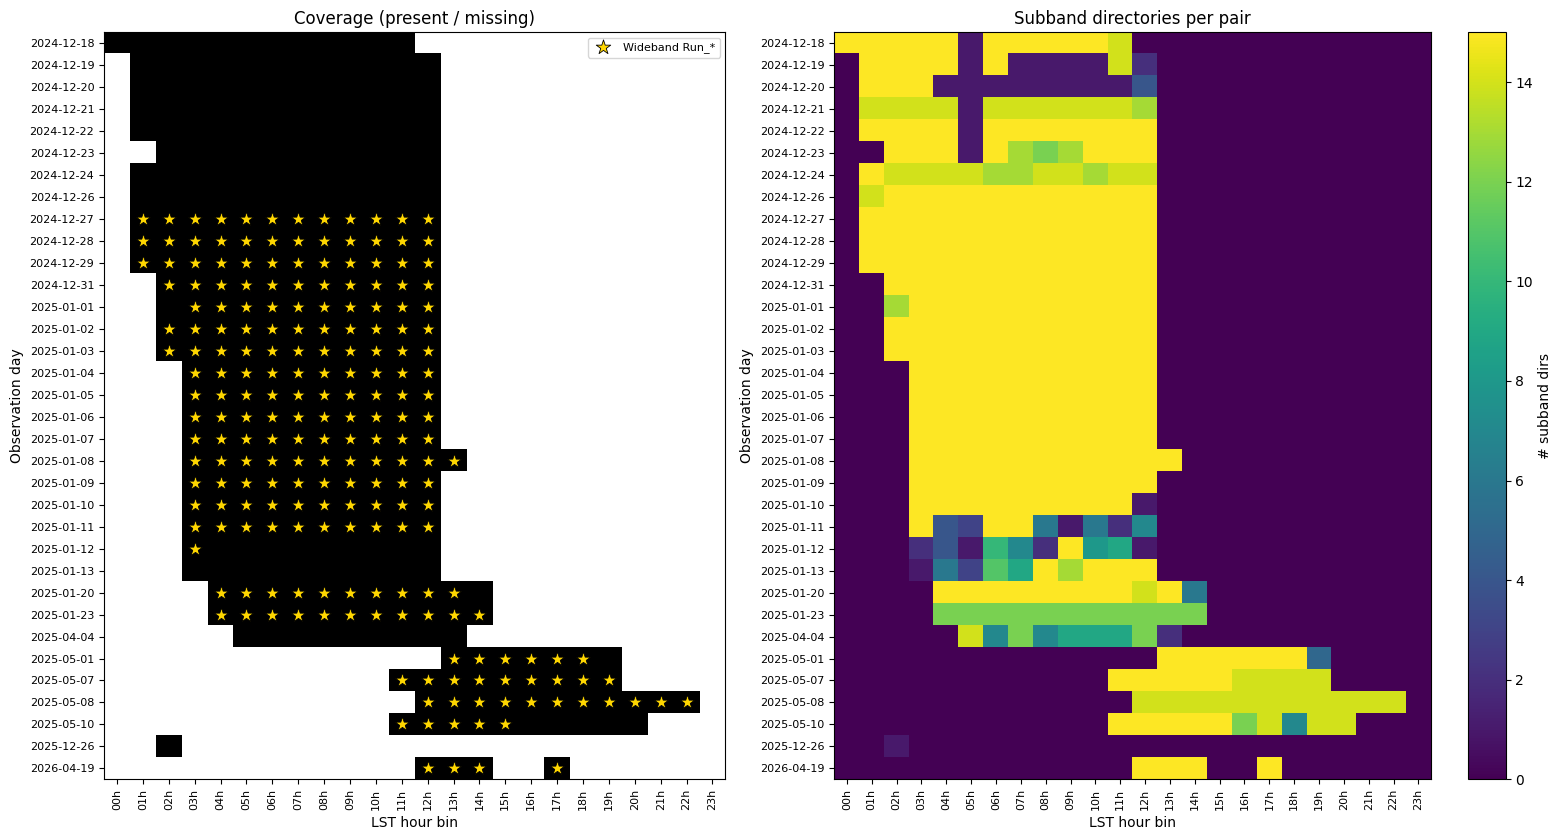

In [7]:
matrix = coverage.pivot_table(
    index="obs_date",
    columns="lst_hour_num",
    values="n_subbands",
    aggfunc="max",
)

wideband_matrix = coverage.pivot_table(
    index="obs_date",
    columns="lst_hour_num",
    values="has_wideband",
    aggfunc="max",
)

all_hours = list(range(24))
matrix = matrix.reindex(columns=all_hours)
wideband_matrix = wideband_matrix.reindex(index=matrix.index, columns=all_hours, fill_value=False)

hour_labels = [f"{h:02d}h" for h in all_hours]
date_labels = [d.strftime("%Y-%m-%d") for d in matrix.index]

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.25 * len(matrix))), gridspec_kw={"width_ratios": [1, 1.2]})

# Presence mask
presence = matrix.notna().astype(float)
im0 = axes[0].imshow(presence.values, aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)
wideband_mask = presence.astype(bool).values & wideband_matrix.fillna(False).astype(bool).values
wideband_y, wideband_x = np.where(wideband_mask)
axes[0].scatter(
    wideband_x,
    wideband_y,
    marker="*",
    s=120,
    c="gold",
    edgecolors="black",
    linewidths=0.6,
    zorder=3,
    label="Wideband Run_*",
)
axes[0].set_title("Coverage (present / missing)")
axes[0].set_xticks(range(len(all_hours)))
axes[0].set_xticklabels(hour_labels, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(date_labels)))
axes[0].set_yticklabels(date_labels, fontsize=8)
axes[0].set_xlabel("LST hour bin")
axes[0].set_ylabel("Observation day")
if wideband_x.size:
    axes[0].legend(loc="upper right", fontsize=8)

# Subband count where present
subband_vals = matrix.fillna(0).values
im1 = axes[1].imshow(subband_vals, aspect="auto", interpolation="nearest", cmap="viridis")
axes[1].set_title("Subband directories per pair")
axes[1].set_xticks(range(len(all_hours)))
axes[1].set_xticklabels(hour_labels, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(date_labels)))
axes[1].set_yticklabels(date_labels, fontsize=8)
axes[1].set_xlabel("LST hour bin")
axes[1].set_ylabel("Observation day")
fig.colorbar(im1, ax=axes[1], label="# subband dirs")

plt.tight_layout()
plt.show()

In [8]:
max_hours = coverage.groupby("obs_date")["lst_hour"].nunique().max()
incomplete_days = day_summary[day_summary["n_lst_hours"] < max_hours].copy()

print(f"Maximum LST hours covered by any single day: {max_hours}")
print(f"Days with incomplete hour coverage: {len(incomplete_days)}")
display(incomplete_days)

sparse_hours = hour_summary.nsmallest(5, "n_days")
print("\nHour bins with the fewest observation days:")
display(sparse_hours)

Maximum LST hours covered by any single day: 12
Days with incomplete hour coverage: 24


,obs_date,n_lst_hours,lst_hours,n_subbands_min,n_subbands_max,n_subbands_median,n_multi_run_pairs
5,2024-12-23,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",1,15,15.0,1
11,2024-12-31,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",15,15,15.0,0
12,2025-01-01,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",13,15,15.0,1
13,2025-01-02,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",15,15,15.0,0
14,2025-01-03,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",15,15,15.0,0
15,2025-01-04,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
16,2025-01-05,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
17,2025-01-06,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
18,2025-01-07,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
19,2025-01-08,11,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 1...",15,15,15.0,0



Hour bins with the fewest observation days:


,lst_hour,n_days,first_day,last_day,n_subbands_median
0,00h,1,2024-12-18,2024-12-18,15.0
21,21h,1,2025-05-08,2025-05-08,14.0
22,22h,1,2025-05-08,2025-05-08,14.0
20,20h,2,2025-05-08,2025-05-10,14.0
15,15h,4,2025-05-01,2025-05-10,15.0
